<a href="https://colab.research.google.com/github/aumer1800/Ecommerce_Customer_Segmentation/blob/main/E_Commerce_CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# upload kaggle json file

In [ ]:
from google.colab import files
upload = files.upload()

Saving kaggle (2).json to kaggle (2).json


#download dataset directly from kaggle

In [ ]:
# Install Kaggle if needed
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d datascikhan/e-commerce-customer-segmentation-2026

Dataset URL: https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026
License(s): CC0-1.0
100% 3.98M/3.98M [00:01<00:00, 2.86MB/s]



#unzip the dataset

In [ ]:
import zipfile

with zipfile.ZipFile("e-commerce-customer-segmentation-2026.zip", "r") as zip_ref:
    zip_ref.extractall("customer-segmentation")

# check dataset structure

In [ ]:
import os
for root,dirs ,files in os.walk("customer-segmentation"):
  for file in files:
    print(os.path.join(root , file))

customer-segmentation/E-commerce_Customer_Segmentation_2026.csv


# Load the dataset

In [ ]:
import pandas as pd
df = pd.read_csv("customer-segmentation/E-commerce_Customer_Segmentation_2026.csv")

# Data Cleaning steps:

In [ ]:
df.shape

(50000, 53)

In [ ]:
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [ ]:
df.isnull().sum()

,0
customer_id,0
customer_segment,0
segment_category,0
age,0
age_group,0
gender,0
country,0
city,0
income_bracket,0
education_level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   segment_category               50000 non-null  object 
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  object 
 5   gender                         50000 non-null  object 
 6   country                        50000 non-null  object 
 7   city                           50000 non-null  object 
 8   income_bracket                 50000 non-null  object 
 9   education_level                50000 non-null  object 
 10  employment_type                50000 non-null  object 
 11  marital_status                 50000 non-null  object 
 12  tenure_months                  50000 non-null 

In [ ]:
df.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,...,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.0
mean,45.64802,59.748240,99.418460,505.366911,50266.546156,62.971240,9.511740,6.99380,3.007960,0.500319,...,57722.068910,102.453505,57619.615405,3.954040,4.122720,3.717700,11.794460,26.84122,86.674100,2026.0
std,18.36795,34.310128,57.780178,285.604037,44071.209164,93.281404,5.782592,4.32425,1.417976,0.289515,...,52437.283546,56.373987,52437.172654,1.478949,1.077573,1.358633,2.680507,19.20729,16.107113,0.0
min,18.00000,1.000000,0.000000,10.050000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,...,0.000000,5.010000,-199.870000,1.000000,1.000000,1.000000,3.000000,0.00000,30.000000,2026.0
25%,30.00000,30.000000,49.000000,259.067500,13893.577500,2.000000,4.000000,3.00000,2.000000,0.251000,...,15488.650000,53.820000,15372.800000,3.000000,3.000000,3.000000,10.000000,10.00000,75.000000,2026.0
50%,45.00000,60.000000,99.000000,504.790000,37541.625000,19.000000,10.000000,7.00000,3.000000,0.500000,...,42236.310000,102.320000,42129.690000,5.000000,4.000000,4.000000,12.000000,25.00000,95.000000,2026.0
75%,60.00000,90.000000,150.000000,752.702500,76811.242500,77.000000,15.000000,11.00000,4.000000,0.752000,...,86714.875000,151.260000,86608.330000,5.000000,5.000000,5.000000,14.000000,40.00000,100.000000,2026.0
max,84.00000,119.000000,199.000000,999.990000,198574.140000,365.000000,19.000000,14.00000,5.000000,1.000000,...,294634.150000,200.000000,294479.720000,5.000000,5.000000,5.000000,15.000000,100.00000,100.000000,2026.0


# Useful features

In [ ]:
features = [
    "age",
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase",
    "return_count",
    "complaint_count",
    "satisfaction_score",
    "email_open_rate",
    "click_through_rate",
    "conversion_rate",
    "customer_lifetime_value_usd",
    "customer_acquisition_cost_usd",
    "customer_profitability_usd"
]

X = df[features].copy()

print("Clustering dataset shape:", X.shape)
X.head()

Clustering dataset shape: (50000, 16)


,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd
0,70,77,28,912.60,25552.80,Quarterly,63,15,13,5,0.018,0.067,0.022,21281.07,96.74,21184.33
1,53,80,75,300.86,22564.50,Rarely,342,1,14,5,0.084,0.085,0.293,28347.21,199.28,28147.93
2,82,86,163,663.91,108217.33,Quarterly,64,1,4,3,0.279,0.428,0.222,103909.84,112.39,103797.45
3,18,26,192,613.60,117811.20,Weekly,2,11,8,5,0.899,0.282,0.142,171318.41,140.71,171177.70
4,64,90,31,651.65,20201.15,Weekly,4,7,11,1,0.835,0.094,0.180,24465.47,52.82,24412.65


In [ ]:
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   tenure_months                  50000 non-null  int64  
 2   total_purchases                50000 non-null  int64  
 3   avg_order_value_usd            50000 non-null  float64
 4   total_spent_usd                50000 non-null  float64
 5   purchase_frequency             50000 non-null  object 
 6   days_since_last_purchase       50000 non-null  int64  
 7   return_count                   50000 non-null  int64  
 8   complaint_count                50000 non-null  int64  
 9   satisfaction_score             50000 non-null  int64  
 10  email_open_rate                50000 non-null  float64
 11  click_through_rate             50000 non-null  float64
 12  conversion_rate                50000 non-null 

In [ ]:
df[features].describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,45.64802,59.748240,99.418460,505.366911,50266.546156,62.971240,9.511740,6.99380,3.007960,0.500319,0.250748,0.150368,57722.068910,102.453505,57619.615405
std,18.36795,34.310128,57.780178,285.604037,44071.209164,93.281404,5.782592,4.32425,1.417976,0.289515,0.144259,0.086877,52437.283546,56.373987,52437.172654
min,18.00000,1.000000,0.000000,10.050000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,5.010000,-199.870000
25%,30.00000,30.000000,49.000000,259.067500,13893.577500,2.000000,4.000000,3.00000,2.000000,0.251000,0.127000,0.075000,15488.650000,53.820000,15372.800000
50%,45.00000,60.000000,99.000000,504.790000,37541.625000,19.000000,10.000000,7.00000,3.000000,0.500000,0.251000,0.150000,42236.310000,102.320000,42129.690000
75%,60.00000,90.000000,150.000000,752.702500,76811.242500,77.000000,15.000000,11.00000,4.000000,0.752000,0.375250,0.226000,86714.875000,151.260000,86608.330000
max,84.00000,119.000000,199.000000,999.990000,198574.140000,365.000000,19.000000,14.00000,5.000000,1.000000,0.500000,0.300000,294634.150000,200.000000,294479.720000


In [ ]:
X["purchase_frequency"].value_counts()

,count
purchase_frequency,
Rarely,10184
Daily,10027
Quarterly,9977
Monthly,9928
Weekly,9884


In [ ]:
X["purchase_frequency"].unique()

array(['Quarterly', 'Rarely', 'Weekly', 'Daily', 'Monthly'], dtype=object)

Convert category into number

In [ ]:
frequency_mapping = {
    "Rarely": 1,
    "Quarterly": 2,
    "Monthly": 3,
    "Weekly": 4,
    "Daily": 5
}

X["purchase_frequency"] = X["purchase_frequency"].map(frequency_mapping)

In [ ]:
X["purchase_frequency"].value_counts().sort_index()

,count
purchase_frequency,
1,10184
2,9977
3,9928
4,9884
5,10027


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   tenure_months                  50000 non-null  int64  
 2   total_purchases                50000 non-null  int64  
 3   avg_order_value_usd            50000 non-null  float64
 4   total_spent_usd                50000 non-null  float64
 5   purchase_frequency             50000 non-null  int64  
 6   days_since_last_purchase       50000 non-null  int64  
 7   return_count                   50000 non-null  int64  
 8   complaint_count                50000 non-null  int64  
 9   satisfaction_score             50000 non-null  int64  
 10  email_open_rate                50000 non-null  float64
 11  click_through_rate             50000 non-null  float64
 12  conversion_rate                50000 non-null 

In [ ]:
X.dtypes

,0
age,int64
tenure_months,int64
total_purchases,int64
avg_order_value_usd,float64
total_spent_usd,float64
purchase_frequency,int64
days_since_last_purchase,int64
return_count,int64
complaint_count,int64
satisfaction_score,int64


# ii.EDA steps:


---

feature distribution

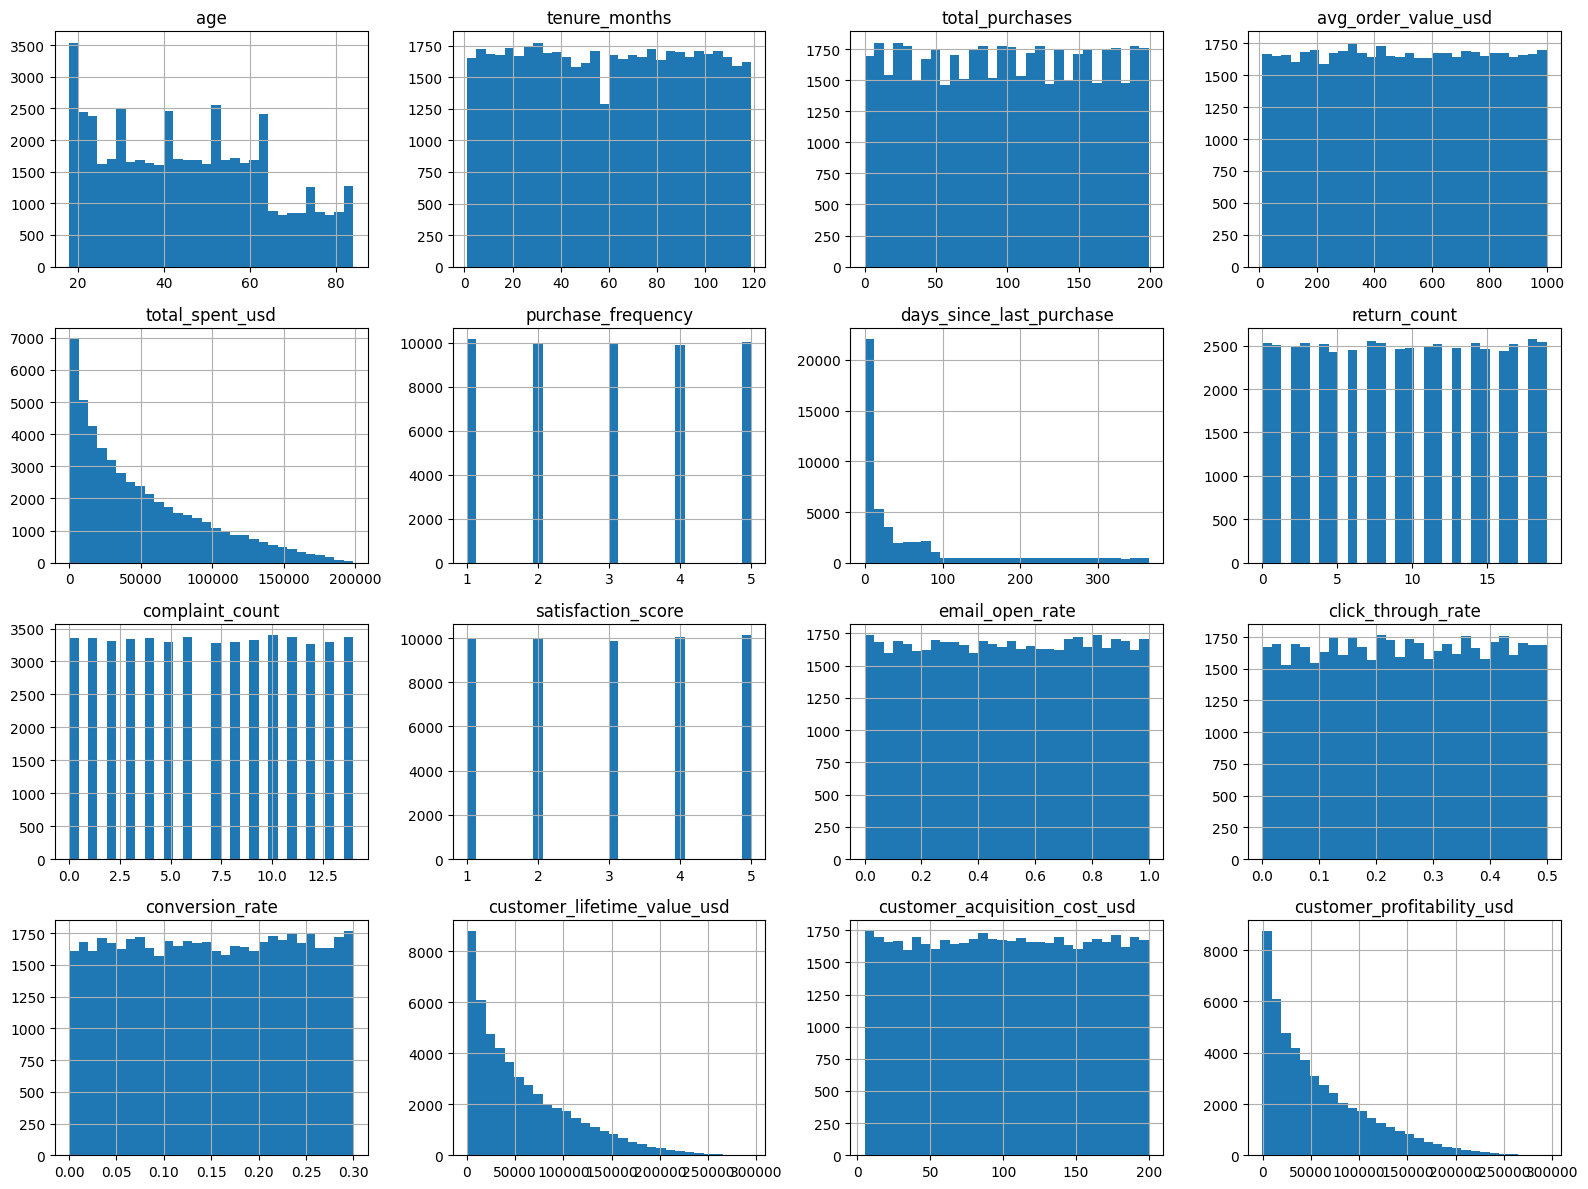

In [ ]:
import matplotlib.pyplot as plt

X.hist(figsize=(16, 12), bins=30)

plt.tight_layout()
plt.show()

Outlier Analysis

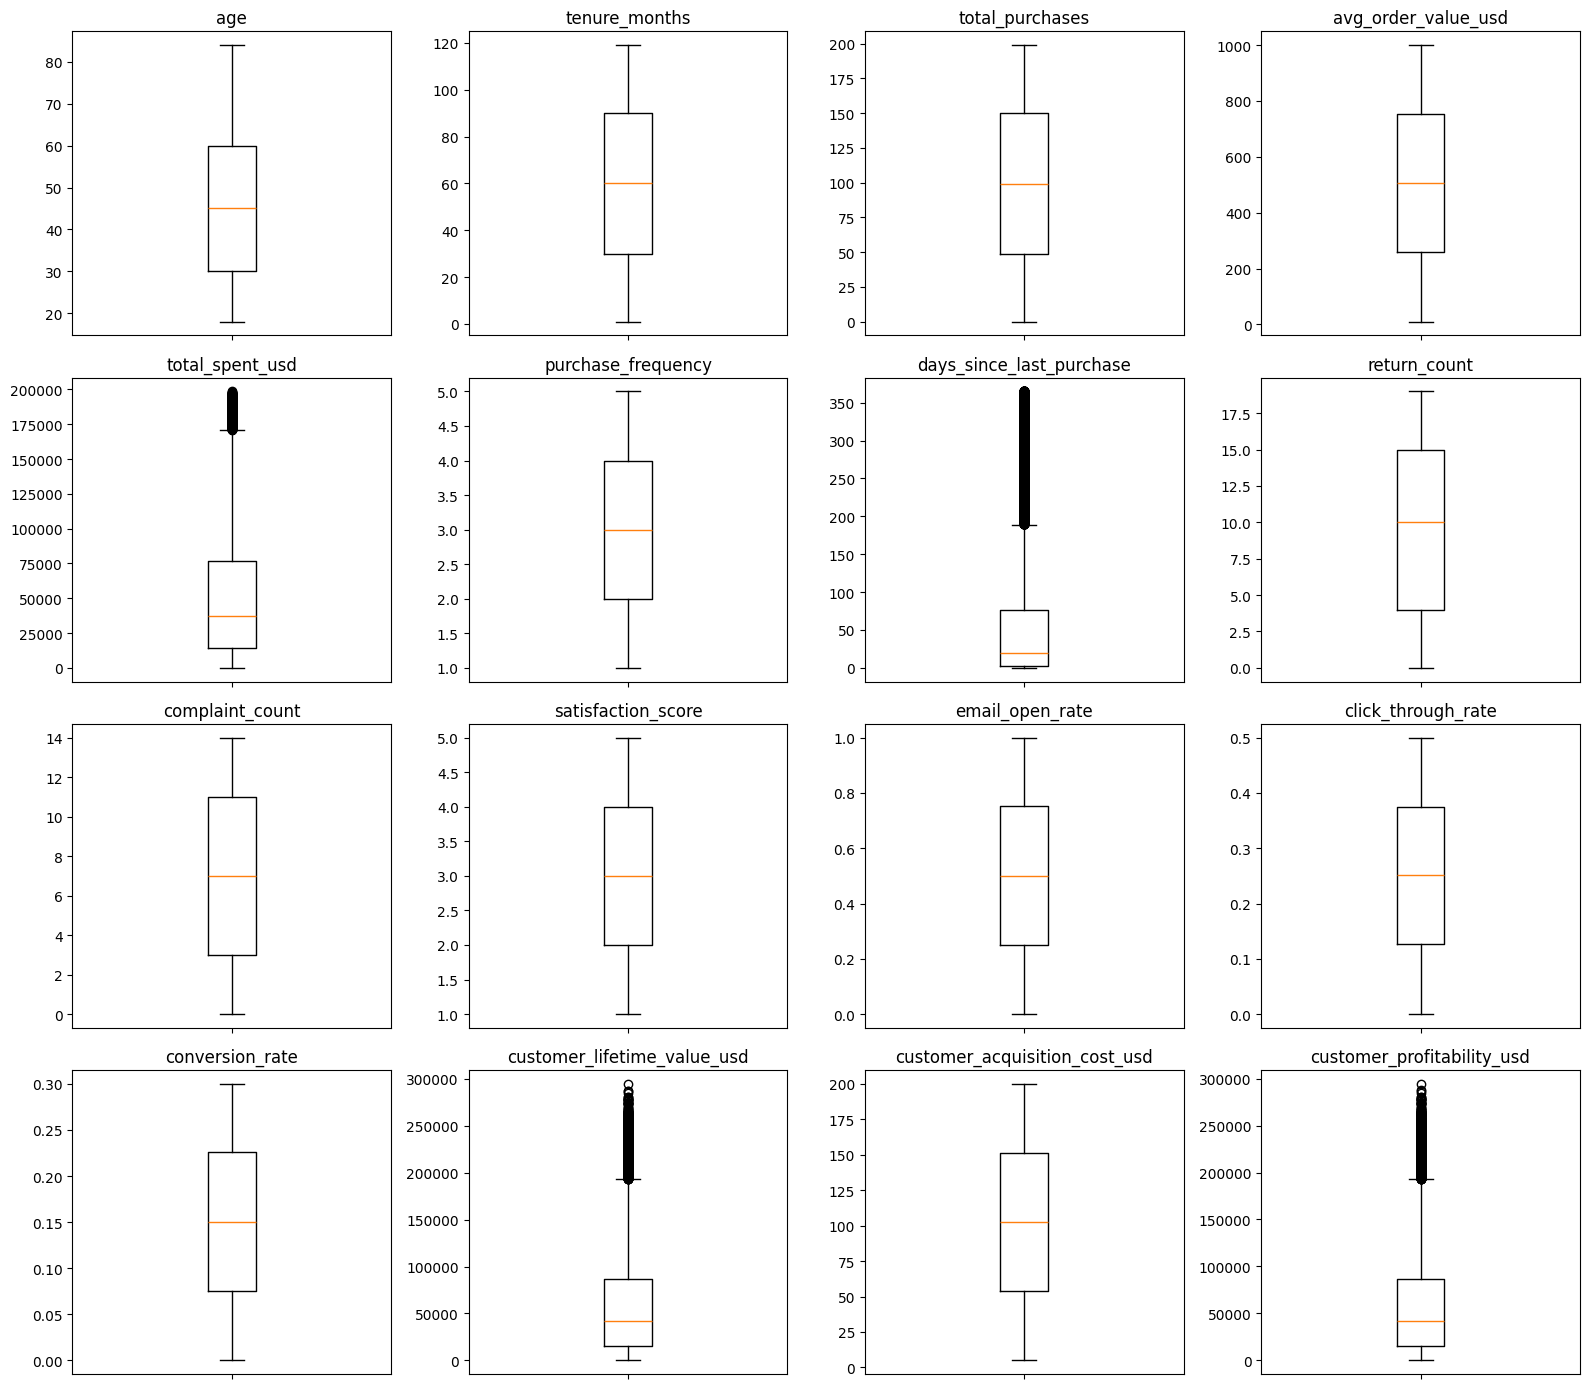

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for i, column in enumerate(X.columns):
    axes[i // 4, i % 4].boxplot(X[column])
    axes[i // 4, i % 4].set_title(column)
    axes[i // 4, i % 4].tick_params(axis="x", labelbottom=False)

plt.tight_layout()
plt.show()

Correlation analysis

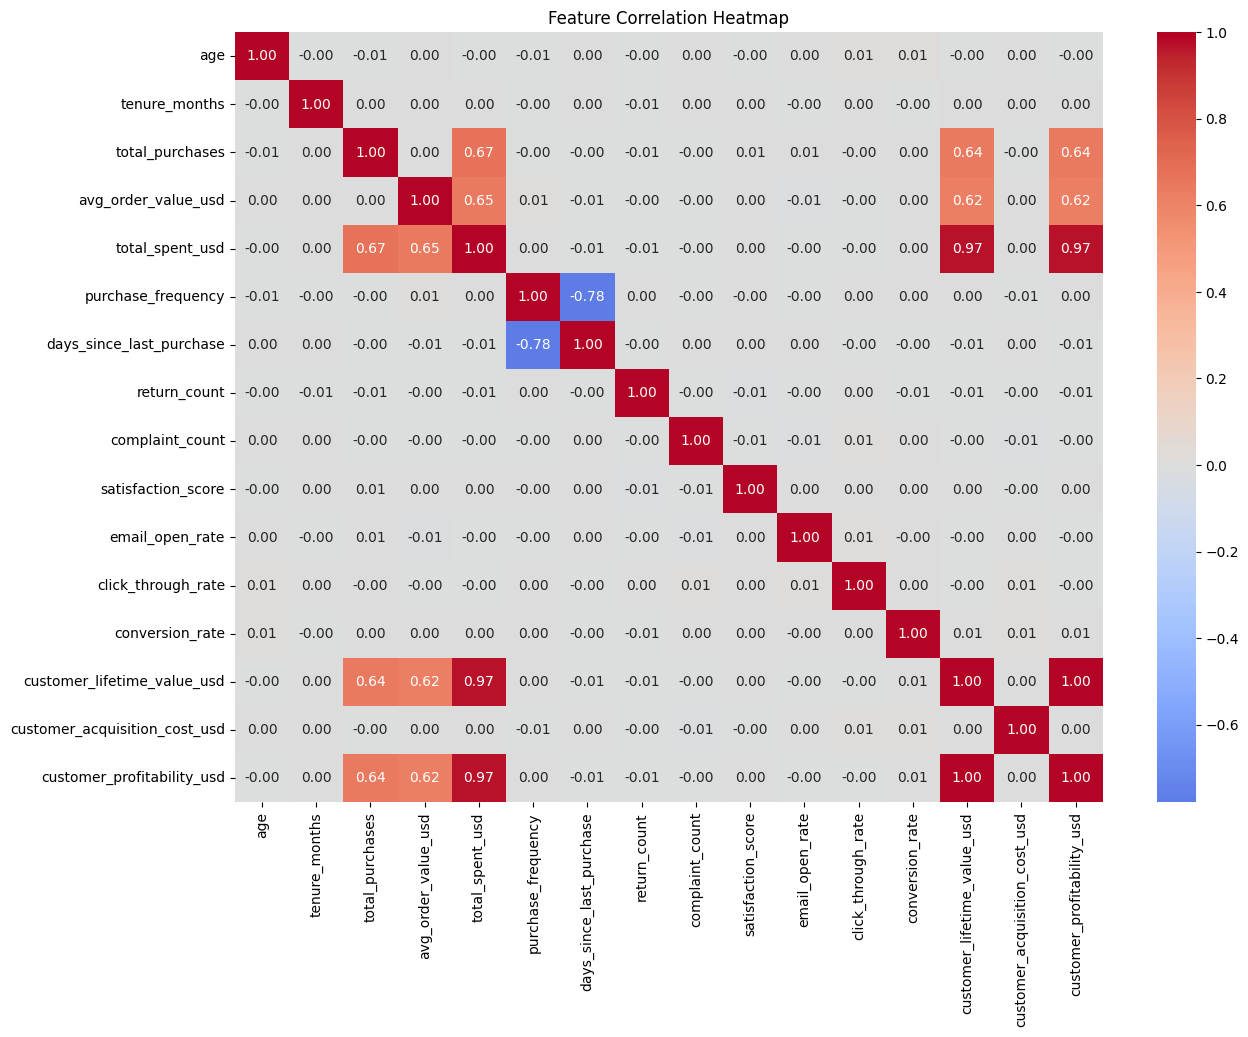

In [ ]:
import seaborn as sns

corr = X.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

Skew Analysis

In [ ]:
skewness_df = pd.DataFrame({
    "Skewness": X.skew()
}).sort_values("Skewness", ascending=False)

skewness_df

,Skewness
days_since_last_purchase,1.759770
customer_lifetime_value_usd,1.159716
customer_profitability_usd,1.159708
total_spent_usd,0.974091
age,0.271793
purchase_frequency,0.007768
tenure_months,0.005509
total_purchases,0.002185
complaint_count,0.001344
avg_order_value_usd,0.001036


Feature statistics

In [ ]:
feature_summary = pd.DataFrame({
    "Min": X.min(),
    "Max": X.max(),
    "Mean": X.mean(),
    "Median": X.median(),
    "Std": X.std(),
    "Skewness": X.skew()
})

feature_summary

,Min,Max,Mean,Median,Std,Skewness
age,18.00,84.00,45.648020,45.000,18.367950,0.271793
tenure_months,1.00,119.00,59.748240,60.000,34.310128,0.005509
total_purchases,0.00,199.00,99.418460,99.000,57.780178,0.002185
avg_order_value_usd,10.05,999.99,505.366911,504.790,285.604037,0.001036
total_spent_usd,0.00,198574.14,50266.546156,37541.625,44071.209164,0.974091
purchase_frequency,1.00,5.00,2.991860,3.000,1.419181,0.007768
days_since_last_purchase,0.00,365.00,62.971240,19.000,93.281404,1.759770
return_count,0.00,19.00,9.511740,10.000,5.782592,-0.000916
complaint_count,0.00,14.00,6.993800,7.000,4.324250,0.001344
satisfaction_score,1.00,5.00,3.007960,3.000,1.417976,-0.007778


Total Purchases vs Total Spent

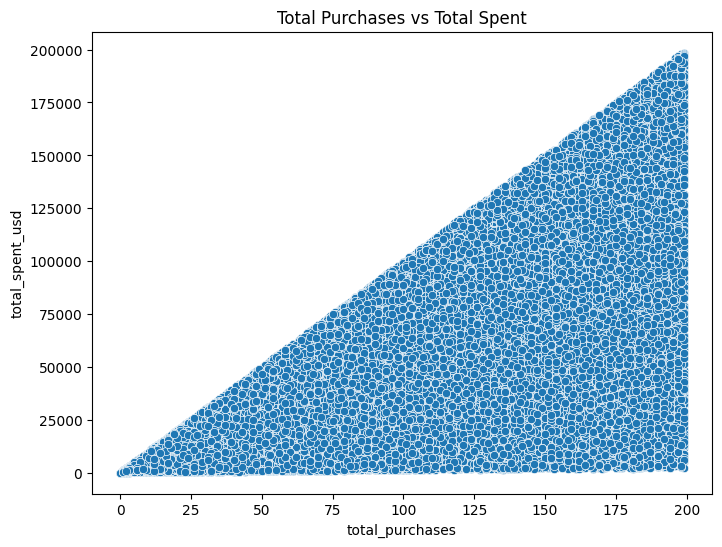

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=X,
    x="total_purchases",
    y="total_spent_usd"
)

plt.title("Total Purchases vs Total Spent")
plt.show()

Average Order Value vs Total Spent

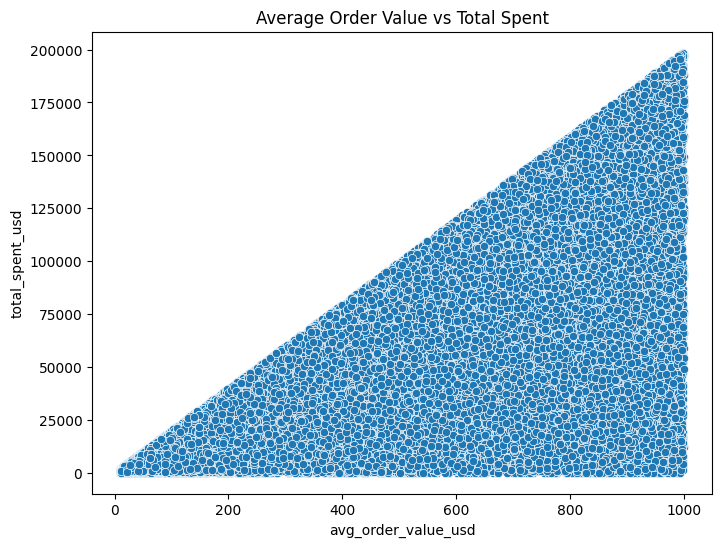

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=X,
    x="avg_order_value_usd",
    y="total_spent_usd"
)

plt.title("Average Order Value vs Total Spent")
plt.show()

Customer Lifetime Value vs Profitability

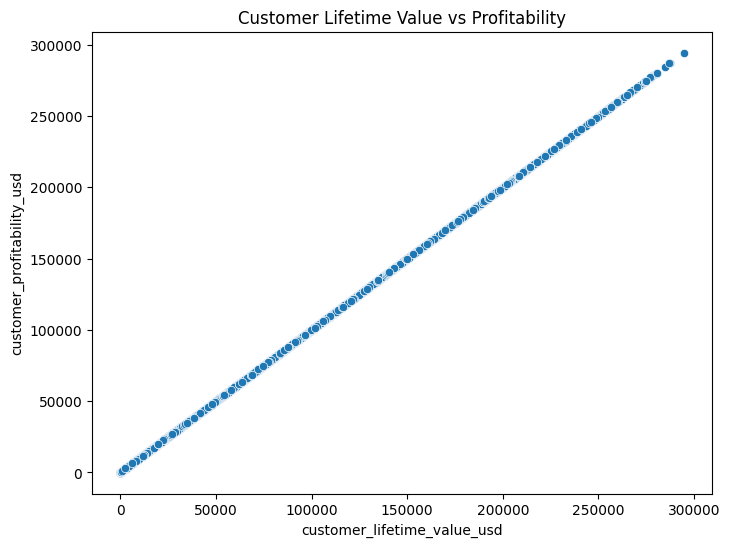

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=X,
    x="customer_lifetime_value_usd",
    y="customer_profitability_usd"
)

plt.title("Customer Lifetime Value vs Profitability")
plt.show()

In [ ]:
print(X["purchase_frequency"].dtype)
print(X["purchase_frequency"].value_counts(dropna=False))

int64
purchase_frequency
1    10184
5    10027
2     9977
3     9928
4     9884
Name: count, dtype: int64


In [ ]:
X = X.drop(columns=["customer_lifetime_value_usd"])

In [ ]:
print(X.shape)
print(X.columns.tolist())

(50000, 15)
['age', 'tenure_months', 'total_purchases', 'avg_order_value_usd', 'total_spent_usd', 'purchase_frequency', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'customer_acquisition_cost_usd', 'customer_profitability_usd']


#Preprocessing


---
Handle skewed features



In [ ]:
import numpy as np

X["days_since_last_purchase"] = np.log1p(
    X["days_since_last_purchase"]
)

X["total_spent_usd"] = np.log1p(
    X["total_spent_usd"]
)

In [ ]:
X[[
    "days_since_last_purchase",
    "total_spent_usd",
    "customer_profitability_usd"
]].skew()

,0
days_since_last_purchase,-0.026366
total_spent_usd,-2.312588
customer_profitability_usd,1.159708


Standardize the features



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [ ]:
X_scaled.head()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_acquisition_cost_usd,customer_profitability_usd
0,1.325800,0.502823,-1.236050,1.425880,-0.044075,-0.698903,0.713498,0.949110,1.388972,1.404861,-1.665974,-1.273751,-1.477593,-0.101351,-0.694844
1,0.400265,0.590262,-0.422614,-0.716058,-0.127731,-1.403542,1.632621,-1.471974,1.620228,1.404861,-1.438004,-1.148975,1.641783,1.717591,-0.562044
2,1.979118,0.765139,1.100415,0.555121,0.926837,-0.698903,0.721986,-1.471974,-0.692335,-0.005614,-0.764457,1.228714,0.824529,0.176262,0.880640
3,-1.505247,-0.983633,1.602322,0.378966,0.983974,0.710375,-0.961916,0.257372,0.232690,1.404861,1.377078,0.216637,-0.096320,0.678626,2.165624
4,0.999141,0.881724,-1.184128,0.512194,-0.202151,0.710375,-0.682253,-0.434367,0.926459,-1.416089,1.156017,-1.086586,0.341084,-0.880442,-0.633278


In [ ]:
X_scaled.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_acquisition_cost_usd,customer_profitability_usd
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,-1.472245e-16,-7.815970e-17,6.963319e-17,-1.401190e-16,-8.348877e-17,1.236344e-17,1.928413e-16,6.053824e-17,-5.215384e-17,-1.519140e-16,1.067768e-16,4.141398e-16,1.872280e-17,3.812772e-16,1.854517e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.505247e+00,-1.712288e+00,-1.720650e+00,-1.734296e+00,-6.870716e+00,-1.403542e+00,-1.563377e+00,-1.644909e+00,-1.617360e+00,-1.416089e+00,-1.728148e+00,-1.738198e+00,-1.730827e+00,-1.728536e+00,-1.102654e+00
25%,-8.519283e-01,-8.670483e-01,-8.725997e-01,-8.623893e-01,-4.539255e-01,-6.989032e-01,-9.619164e-01,-9.531703e-01,-9.235914e-01,-7.108511e-01,-8.611714e-01,-8.578291e-01,-8.675308e-01,-8.627027e-01,-8.056735e-01
50%,-3.528028e-02,7.337848e-03,-7.242348e-03,-2.019987e-03,2.146961e-01,5.735761e-03,7.670501e-02,8.443703e-02,1.433789e-03,-5.613690e-03,-1.103236e-03,1.743546e-03,-4.234755e-03,-2.368226e-03,-2.954027e-01
75%,7.813677e-01,8.817240e-01,8.754221e-01,8.660174e-01,6.962534e-01,7.103747e-01,8.218025e-01,9.491098e-01,9.264590e-01,6.996238e-01,8.693272e-01,8.630492e-01,8.705719e-01,8.657714e-01,5.528331e-01
max,2.088005e+00,1.726964e+00,1.723472e+00,1.731866e+00,1.335160e+00,1.415014e+00,1.668154e+00,1.640848e+00,1.620228e+00,1.404861e+00,1.725941e+00,1.727821e+00,1.722357e+00,1.730363e+00,4.517072e+00


#Elbow Method

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

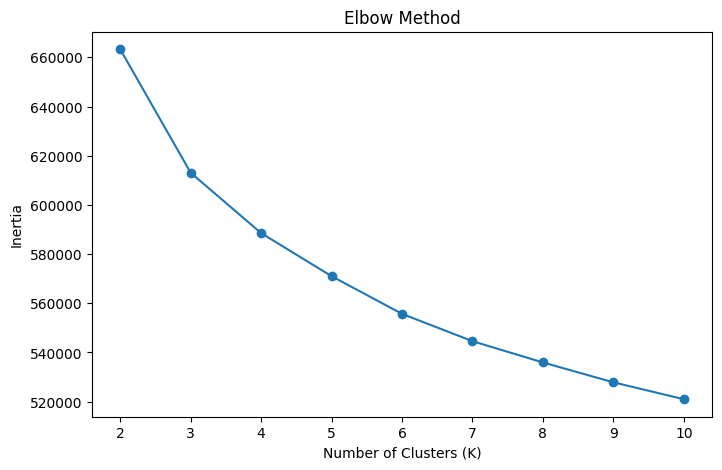

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
X["total_spent_usd"] = df["total_spent_usd"]

In [ ]:
print(X["total_spent_usd"].skew())

0.974090698899651


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

X[[
    "total_spent_usd",
    "customer_profitability_usd"
]] = pt.fit_transform(
    X[[
        "total_spent_usd",
        "customer_profitability_usd"
    ]]
)

In [ ]:
print(
    X[[
        "total_spent_usd",
        "customer_profitability_usd"
    ]].skew()
)

total_spent_usd              -0.139998
customer_profitability_usd    0.221433
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [ ]:
X_scaled.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_acquisition_cost_usd,customer_profitability_usd
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,-1.472245e-16,-7.815970e-17,6.963319e-17,-1.401190e-16,1.502798e-16,1.236344e-17,1.928413e-16,6.053824e-17,-5.215384e-17,-1.519140e-16,1.067768e-16,4.141398e-16,1.872280e-17,3.812772e-16,1.164580e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.505247e+00,-1.712288e+00,-1.720650e+00,-1.734296e+00,-2.589792e+00,-1.403542e+00,-1.563377e+00,-1.644909e+00,-1.617360e+00,-1.416089e+00,-1.728148e+00,-1.738198e+00,-1.730827e+00,-1.728536e+00,-5.026113e+00
25%,-8.519283e-01,-8.670483e-01,-8.725997e-01,-8.623893e-01,-7.490054e-01,-6.989032e-01,-9.619164e-01,-9.531703e-01,-9.235914e-01,-7.108511e-01,-8.611714e-01,-8.578291e-01,-8.675308e-01,-8.627027e-01,-7.894551e-01
50%,-3.528028e-02,7.337848e-03,-7.242348e-03,-2.019987e-03,3.059992e-02,5.735761e-03,7.670501e-02,8.443703e-02,1.433789e-03,-5.613690e-03,-1.103236e-03,1.743546e-03,-4.234755e-03,-2.368226e-03,-9.261458e-02
75%,7.813677e-01,8.817240e-01,8.754221e-01,8.660174e-01,7.822824e-01,7.103747e-01,8.218025e-01,9.491098e-01,9.264590e-01,6.996238e-01,8.693272e-01,8.630492e-01,8.705719e-01,8.657714e-01,7.107356e-01
max,2.088005e+00,1.726964e+00,1.723472e+00,1.731866e+00,2.112938e+00,1.415014e+00,1.668154e+00,1.640848e+00,1.620228e+00,1.404861e+00,1.725941e+00,1.727821e+00,1.722357e+00,1.730363e+00,3.093415e+00


#Calculate Silhouette Score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

print(silhouette_scores)

{2: np.float64(0.12123121566632498), 3: np.float64(0.10118809451280089), 4: np.float64(0.08278666403505518), 5: np.float64(0.07530388455687294), 6: np.float64(0.07247145984852388), 7: np.float64(0.06552797353230311), 8: np.float64(0.061264100294141574), 9: np.float64(0.05856508516227001), 10: np.float64(0.058216610729798904)}


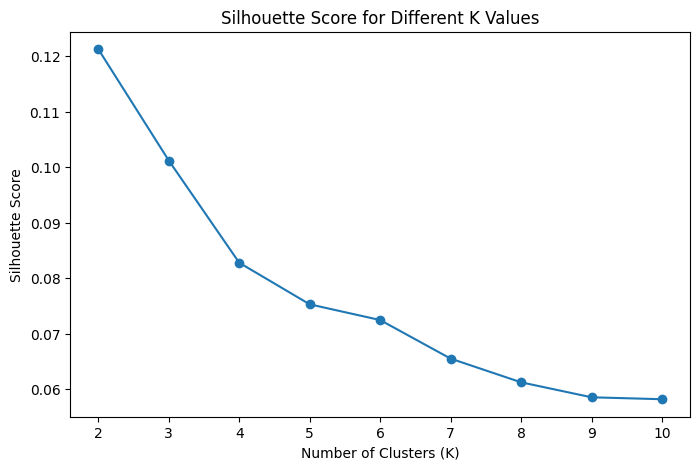

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

Choose the final K

In [ ]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

X["cluster"] = kmeans.fit_predict(X_scaled)

X["cluster"].value_counts().sort_index()

,count
cluster,
0,10600
1,13360
2,10097
3,15943


In [ ]:
df_clustered = df.copy()

df_clustered["cluster"] = X["cluster"]

df_clustered.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category,cluster
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV,3
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV,3
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV,1
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV,2
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV,0


In [ ]:
# Create clustered dataset from original data
df_clustered = df.copy()

# Add cluster labels
df_clustered["cluster"] = X["cluster"]

# Convert purchase frequency to numeric
df_clustered["purchase_frequency"] = df_clustered[
    "purchase_frequency"
].map(frequency_mapping)

# Create profile features
profile_features = [
    "age",
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase",
    "return_count",
    "complaint_count",
    "satisfaction_score",
    "email_open_rate",
    "click_through_rate",
    "conversion_rate",
    "customer_lifetime_value_usd",
    "customer_acquisition_cost_usd",
    "customer_profitability_usd"
]

# Calculate cluster averages
cluster_profile = (
    df_clustered.groupby("cluster")[profile_features]
    .mean()
    .round(2)
)

cluster_profile

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd
cluster,,,,,,,,,,,,,,,,
0,45.48,60.24,66.14,349.29,15920.28,4.45,2.49,9.70,6.99,3.00,0.5,0.25,0.15,18019.14,103.98,17915.16
1,45.95,60.28,136.53,680.67,89807.10,1.97,105.03,9.50,6.98,2.99,0.5,0.25,0.15,103369.35,103.14,103266.21
2,45.21,59.30,132.59,668.98,85360.75,4.44,2.50,9.45,6.93,3.03,0.5,0.25,0.15,98429.02,100.72,98328.30
3,45.78,59.27,69.44,358.61,17742.09,1.96,106.23,9.43,7.05,3.01,0.5,0.25,0.15,20087.07,101.96,19985.11


Check cluster sizes

In [ ]:
cluster_sizes = (
    df_clustered["cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

,count
cluster,
0,10600
1,13360
2,10097
3,15943


In [ ]:
cluster_percentage = (
    df_clustered["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_percentage

,proportion
cluster,
0,21.20
1,26.72
2,20.19
3,31.89


In [ ]:
summary_features = [
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase",
    "customer_lifetime_value_usd",
    "customer_profitability_usd"
]

cluster_summary = (
    df_clustered.groupby("cluster")[summary_features]
    .mean()
    .round(2)
)

cluster_summary

,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,customer_lifetime_value_usd,customer_profitability_usd
cluster,,,,,,,
0,66.14,349.29,15920.28,4.45,2.49,18019.14,17915.16
1,136.53,680.67,89807.10,1.97,105.03,103369.35,103266.21
2,132.59,668.98,85360.75,4.44,2.50,98429.02,98328.30
3,69.44,358.61,17742.09,1.96,106.23,20087.07,19985.11


In [ ]:
cluster_names = {
    0: "Frequent Low-Spending Customers",
    1: "High-Value At-Risk Customers",
    2: "High-Value Loyal Customers",
    3: "Low-Engagement Customers"
}

df_clustered["segment"] = df_clustered["cluster"].map(cluster_names)

df_clustered[["cluster", "segment"]].head()

,cluster,segment
0,3,Low-Engagement Customers
1,3,Low-Engagement Customers
2,1,High-Value At-Risk Customers
3,2,High-Value Loyal Customers
4,0,Frequent Low-Spending Customers


In [ ]:
df_clustered["segment"].value_counts()

,count
segment,
Low-Engagement Customers,15943
High-Value At-Risk Customers,13360
Frequent Low-Spending Customers,10600
High-Value Loyal Customers,10097


#Visualize cluster distribution

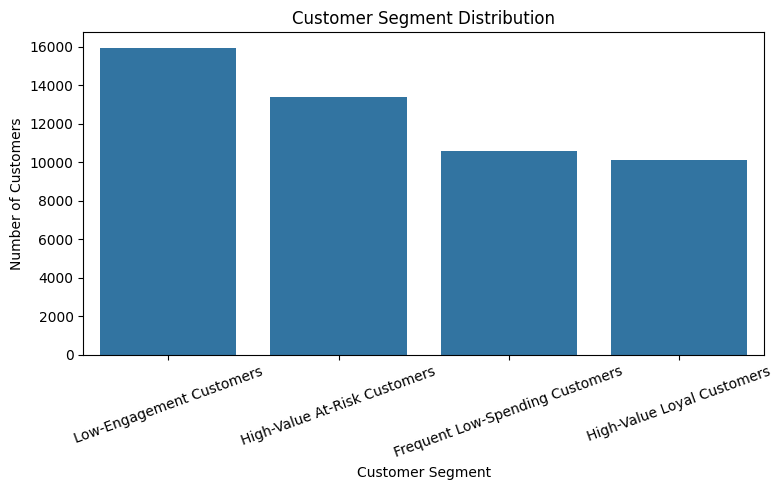

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clustered,
    x="segment",
    order=df_clustered["segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#Compare spending

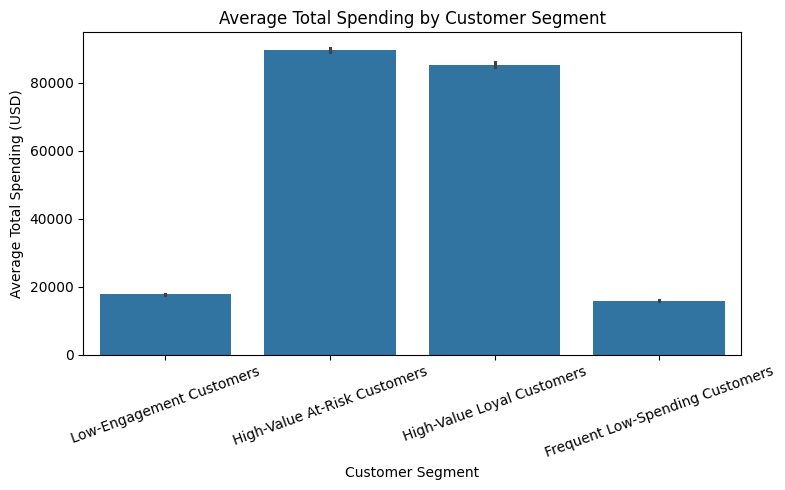

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clustered,
    x="segment",
    y="total_spent_usd",
    estimator="mean"
)

plt.title("Average Total Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending (USD)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#Compare purchase frequency

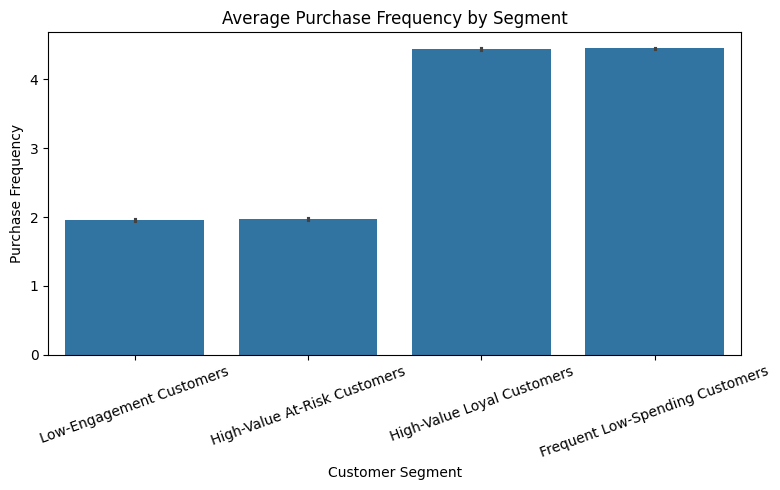

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clustered,
    x="segment",
    y="purchase_frequency",
    estimator="mean"
)

plt.title("Average Purchase Frequency by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Purchase Frequency")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#Compare recency

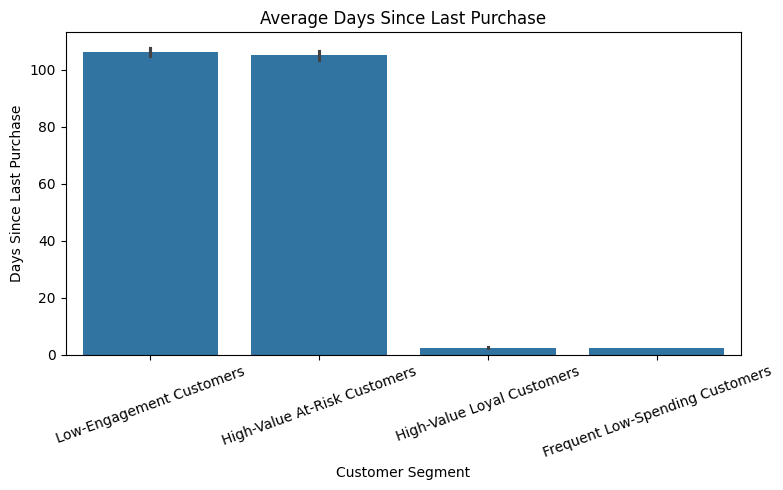

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clustered,
    x="segment",
    y="days_since_last_purchase",
    estimator="mean"
)

plt.title("Average Days Since Last Purchase")
plt.xlabel("Customer Segment")
plt.ylabel("Days Since Last Purchase")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#PCA visualization

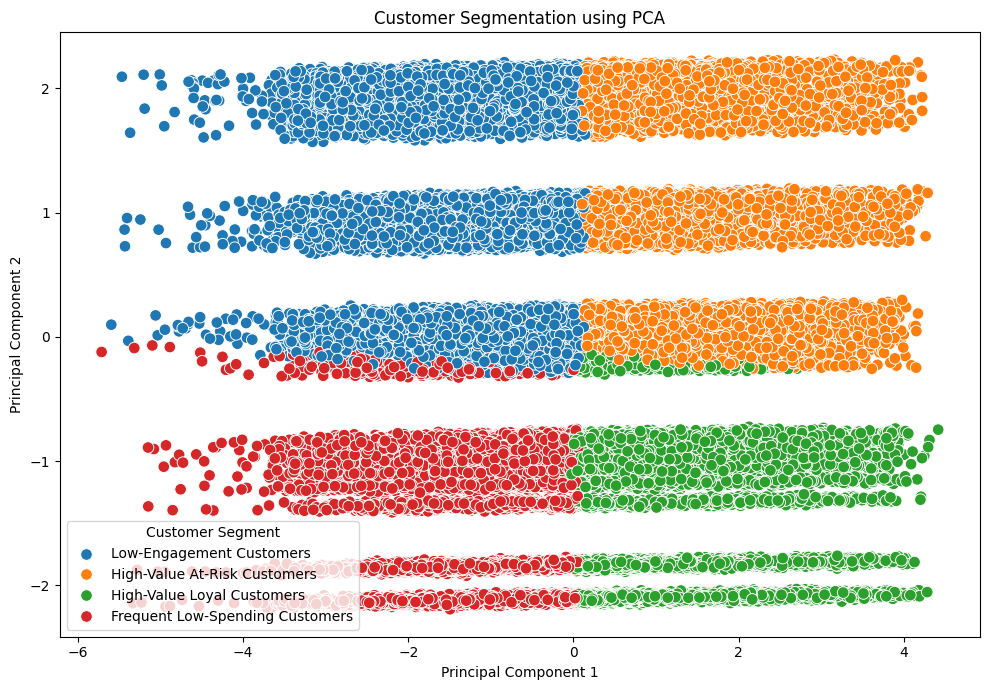

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = X["cluster"]

pca_df["segment"] = pca_df["cluster"].map(cluster_names)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="segment",
    s=70
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

#cluster validation

In [ ]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    X_scaled,
    X["cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.0828


In [ ]:
print("Number of clusters:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))

Number of clusters: 4
Silhouette Score: 0.0828


#cluster summary

In [ ]:
recommendation_summary = (
    df_clustered.groupby(["cluster", "segment"])[
        [
            "total_purchases",
            "total_spent_usd",
            "purchase_frequency",
            "days_since_last_purchase",
            "customer_lifetime_value_usd",
            "customer_profitability_usd"
        ]
    ]
    .mean()
    .round(2)
    .reset_index()
)

recommendation_summary

,cluster,segment,total_purchases,total_spent_usd,purchase_frequency,days_since_last_purchase,customer_lifetime_value_usd,customer_profitability_usd
0,0,Frequent Low-Spending Customers,66.14,15920.28,4.45,2.49,18019.14,17915.16
1,1,High-Value At-Risk Customers,136.53,89807.10,1.97,105.03,103369.35,103266.21
2,2,High-Value Loyal Customers,132.59,85360.75,4.44,2.50,98429.02,98328.30
3,3,Low-Engagement Customers,69.44,17742.09,1.96,106.23,20087.07,19985.11


#Create recommendation

In [ ]:
recommendations = {
    "Frequent Low-Spending Customers":
        "Encourage larger purchases through product bundles, cross-selling, and personalized offers.",

    "High-Value At-Risk Customers":
        "Use re-engagement campaigns, personalized discounts, and loyalty offers to encourage repeat purchases.",

    "High-Value Loyal Customers":
        "Provide loyalty rewards, premium offers, and exclusive products to maintain customer engagement.",

    "Low-Engagement Customers":
        "Use targeted marketing campaigns, product recommendations, and special offers to increase engagement."
}

In [ ]:
for segment, recommendation in recommendations.items():
    print(f"\n{segment}")
    print("-" * len(segment))
    print(recommendation)


Frequent Low-Spending Customers
-------------------------------
Encourage larger purchases through product bundles, cross-selling, and personalized offers.

High-Value At-Risk Customers
----------------------------
Use re-engagement campaigns, personalized discounts, and loyalty offers to encourage repeat purchases.

High-Value Loyal Customers
--------------------------
Provide loyalty rewards, premium offers, and exclusive products to maintain customer engagement.

Low-Engagement Customers
------------------------
Use targeted marketing campaigns, product recommendations, and special offers to increase engagement.


In [ ]:
recommendation_df = pd.DataFrame(
    recommendations.items(),
    columns=["segment", "recommendation"]
)

recommendation_df

,segment,recommendation
0,Frequent Low-Spending Customers,Encourage larger purchases through product bun...
1,High-Value At-Risk Customers,"Use re-engagement campaigns, personalized disc..."
2,High-Value Loyal Customers,"Provide loyalty rewards, premium offers, and e..."
3,Low-Engagement Customers,"Use targeted marketing campaigns, product reco..."


In [ ]:
recommendation_df.to_csv(
    "customer_recommendations.csv",
    index=False
)

In [ ]:
from google.colab import files

recommendation_df.to_csv(
    "customer_recommendations.csv",
    index=False
)

files.download("customer_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(kmeans, "customer_segmentation_kmeans.pkl")

print("K-Means model saved successfully.")

K-Means model saved successfully.


In [ ]:
from google.colab import files

files.download("customer_segmentation_kmeans.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>